In [1]:
import pandas as pd, numpy as np, os
for f in os.listdir('.'):
 print(f)


.kernel_llm_logs_1.txt
omega_class_moments_N1e6.csv
zeta_two_param_loglog_fits.csv
.prompts
memory
.config
omega_class_moments.csv


In [2]:
df1 = pd.read_csv('omega_class_moments.csv')
df2 = pd.read_csv('omega_class_moments_N1e6.csv')
print(df1)
print('---')
print(df2)


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451779 0.262002 
4 159.091605 14.413875 0.233885 0.212927 0.439947 0.273138 
5 181.308525 18.942436 0.450056 0.205916 0.432779 0.278650 
6 168.571130 20.716949 0.153646 0.246829 0.3

In [3]:
print(df2.columns.tolist())
print(df2[['L_function','N_terms']])


['L_function', 'N_terms', 'M_total', 'M_0', 'M_1', 'M_2', 'M_3', 'M_4', 'M_geq5', 'frac_0', 'frac_1', 'frac_2', 'frac_3', 'frac_4', 'frac_geq5']
 L_function N_terms
0 zeta 10000
1 zeta 50000
2 zeta 100000
3 L(Δ) 10000
4 L(Δ) 50000
5 L(Δ) 100000
6 L_DH 10000
7 L_DH 50000
8 L_DH 100000
9 zeta 1000000
10 L(Δ) 1000000
11 L_DH 1000000


In [4]:
# df2 already contains everything (df1 + N=1e6). Use df2.
zeta_ref = pd.read_csv('zeta_two_param_loglog_fits.csv')
print(zeta_ref.columns.tolist())
print(zeta_ref)


['k', 'a_2p_4pts', 'b_2p_4pts', 'logC_2p_4pts', 'se_a_2p', 'se_b_2p', 'R2_2p_4pts', 'R2_1p_4pts', 'a_1p_4pts', 'a_2p_3pts', 'b_2p_3pts', 'a_1p_3pts', 'pct_change_a_2p', 'pct_change_b_2p', 'pct_change_a_1p', 'p_F_2p_vs_1p', 'F_2p_vs_1p']
 k a_2p_4pts b_2p_4pts logC_2p_4pts se_a_2p se_b_2p \
0 M_1 62.466693 -136.856914 -21.946539 1.909166 4.617935 
1 M_2 43.375580 -82.748822 -21.525482 0.530824 1.283971 
2 M_3 34.438728 -56.088214 -23.257879 0.457786 1.107304 
3 M_4 27.857893 -31.523000 -30.886309 0.045208 0.109350 
4 M_geq5 80.469227 -148.055346 -59.539569 11.430739 27.648935 

 R2_2p_4pts R2_1p_4pts a_1p_4pts a_2p_3pts b_2p_3pts a_1p_3pts \
0 0.999921 0.930312 5.909832 53.172454 -115.296206 3.561479 
1 0.999997 0.988786 9.179181 40.791410 -76.754083 7.764782 
2 0.999999 0.996549 11.259969 32.210123 -50.918314 10.300407 
3 1.000000 0.999370 14.830843 27.637812 -31.012456 14.293416 
4 0.999716 0.991561 19.284554 136.116569 -277.145646 16.863160 

 pct_change_a_2p pct_change_b_2p pct_chan

In [5]:
import statsmodels.api as sm

def fit_two_param(df, Lname, kcol):
 sub = df[df['L_function']==Lname].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float)
 M = sub[kcol].values.astype(float)
 logM = np.log(M)
 x1 = np.log(np.log(N))
 x2 = np.log(np.log(np.log(N)))
 X = np.column_stack([np.ones_like(x1), x1, x2])
 res = sm.OLS(logM, X).fit()
 return {
 'logC': res.params[0], 'a': res.params[1], 'b': res.params[2],
 'se_logC': res.bse[0], 'se_a': res.bse[1], 'se_b': res.bse[2],
 'R2': res.rsquared, 'N_points': len(N)
 }

def fit_one_param(df, Lname, kcol):
 sub = df[df['L_function']==Lname].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float)
 M = sub[kcol].values.astype(float)
 logM = np.log(M)
 x1 = np.log(np.log(N))
 X = np.column_stack([np.ones_like(x1), x1])
 res = sm.OLS(logM, X).fit()
 return {'logC': res.params[0], 'a': res.params[1], 'se_a': res.bse[1], 'R2': res.rsquared}

rows = []
for L in ['zeta','L(Δ)','L_DH']:
 for k in ['M_1','M_2','M_3','M_4','M_geq5']:
 r2 = fit_two_param(df2, L, k)
 r1 = fit_one_param(df2, L, k)
 rows.append({'L':L,'k':k,
 'a_2p':r2['a'],'b_2p':r2['b'],'se_a':r2['se_a'],'se_b':r2['se_b'],
 'R2_2p':r2['R2'],'a_1p':r1['a'],'R2_1p':r1['R2']})
fit_df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(fit_df.to_string(index=False))


 L k a_2p b_2p se_a se_b R2_2p a_1p R2_1p
zeta M_1 62.4667 -136.8569 1.9092 4.6179 0.9999 5.9098 0.9303
zeta M_2 43.3756 -82.7488 0.5308 1.2840 1.0000 9.1792 0.9888
zeta M_3 34.4387 -56.0882 0.4578 1.1073 1.0000 11.2600 0.9965
zeta M_4 27.8579 -31.5230 0.0452 0.1093 1.0000 14.8308 0.9994
zeta M_geq5 80.4692 -148.0553 11.4307 27.6489 0.9997 19.2846 0.9916
L(Δ) M_1 -0.8176 2.6785 0.0971 0.2348 0.9999 0.2893 0.9881
L(Δ) M_2 0.9782 -0.4359 0.3399 0.8221 0.9999 0.7980 0.9998
L(Δ) M_3 0.1723 4.4773 0.4118 0.9960 1.0000 2.0225 0.9993
L(Δ) M_4 -24.7289 71.5061 2.7514 6.6552 0.9997 4.8214 0.9700
L(Δ) M_geq5 -24.5693 83.5286 2.5932 6.2726 0.9999 9.9494 0.9902
L_DH M_1 -0.3335 1.2201 0.1511 0.3655 0.9994 0.1707 0.9923
L_DH M_2 -0.2218 1.6986 0.7457 1.8038 0.9980 0.4801 0.9963
L_DH M_3 -2.6937 10.3075 1.1920 2.8832 0.9995 1.5660 0.9935
L_DH M_4 -3.7190 16.4181 4.1249 9.9774 0.9985 3.0658 0.9946
L_DH M_geq5 -82.7049 220.9668 7.0465 17.0442 0.9995 8.6108 0.9154


In [6]:
# Reshape for side-by-side comparison
pivot = fit_df.pivot(index='k', columns='L', values=['a_2p','b_2p','R2_2p'])
print(pivot.to_string())
# Save
fit_df.to_csv('two_param_fits_all_Lfunctions.csv', index=False)
print('\nSaved two_param_fits_all_Lfunctions.csv')


 a_2p b_2p R2_2p 
L L(Δ) L_DH zeta L(Δ) L_DH zeta L(Δ) L_DH zeta
k 
M_1 -0.8176 -0.3335 62.4667 2.6785 1.2201 -136.8569 0.9999 0.9994 0.9999
M_2 0.9782 -0.2218 43.3756 -0.4359 1.6986 -82.7488 0.9999 0.9980 1.0000
M_3 0.1723 -2.6937 34.4387 4.4773 10.3075 -56.0882 1.0000 0.9995 1.0000
M_4 -24.7289 -3.7190 27.8579 71.5061 16.4181 -31.5230 0.9997 0.9985 1.0000
M_geq5 -24.5693 -82.7049 80.4692 83.5286 220.9668 -148.0553 0.9999 0.9995 0.9997

Saved two_param_fits_all_Lfunctions.csv


In [7]:
# Also compute stability: fit on 3 points (10^4, 5e4, 10^5) vs 4 points
def fit_two_param_subset(df, Lname, kcol, Nvals):
 sub = df[(df['L_function']==Lname) & (df['N_terms'].isin(Nvals))].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float)
 M = sub[kcol].values.astype(float)
 if len(N) < 3:
 return None
 logM = np.log(M)
 x1 = np.log(np.log(N))
 x2 = np.log(np.log(np.log(N)))
 if len(N) == 3:
 # exact fit, no residual df; use OLS
 X = np.column_stack([np.ones_like(x1), x1, x2])
 res = sm.OLS(logM, X).fit()
 return {'a': res.params[1], 'b': res.params[2]}
 X = np.column_stack([np.ones_like(x1), x1, x2])
 res = sm.OLS(logM, X).fit()
 return {'a': res.params[1], 'b': res.params[2]}

rows = []
for L in ['zeta','L(Δ)','L_DH']:
 for k in ['M_1','M_2','M_3','M_4','M_geq5']:
 r4 = fit_two_param_subset(df2, L, k, [10000,50000,100000,1000000])
 r3 = fit_two_param_subset(df2, L, k, [10000,50000,100000])
 pct_a = 100*(r4['a']-r3['a'])/r3['a'] if r3['a']!=0 else np.nan
 pct_b = 100*(r4['b']-r3['b'])/r3['b'] if r3['b']!=0 else np.nan
 rows.append({'L':L,'k':k,
 'a_4pt':r4['a'],'a_3pt':r3['a'],'pct_change_a':pct_a,
 'b_4pt':r4['b'],'b_3pt':r3['b'],'pct_change_b':pct_b})
stab_df = pd.DataFrame(rows)
print(stab_df.to_string(index=False))
stab_df.to_csv('two_param_stability_all_Lfunctions.csv', index=False)


 L k a_4pt a_3pt pct_change_a b_4pt b_3pt pct_change_b
zeta M_1 62.4667 53.1725 17.4794 -136.8569 -115.2962 18.7003
zeta M_2 43.3756 40.7914 6.3351 -82.7488 -76.7541 7.8103
zeta M_3 34.4387 32.2101 6.9190 -56.0882 -50.9183 10.1533
zeta M_4 27.8579 27.6378 0.7963 -31.5230 -31.0125 1.6463
zeta M_geq5 80.4692 136.1166 -40.8821 -148.0553 -277.1456 -46.5785
L(Δ) M_1 -0.8176 -1.2903 -36.6314 2.6785 3.7750 -29.0452
L(Δ) M_2 0.9782 2.6328 -62.8471 -0.4359 -4.2743 -89.8015
L(Δ) M_3 0.1723 2.1769 -92.0866 4.4773 -0.1731 -2685.9647
L(Δ) M_4 -24.7289 -38.1235 -35.1348 71.5061 102.5788 -30.2916
L(Δ) M_geq5 -24.5693 -11.9448 105.6896 83.5286 54.2425 53.9910
L_DH M_1 -0.3335 -1.0692 -68.8030 1.2201 2.9266 -58.3089
L_DH M_2 -0.2218 -3.8523 -94.2416 1.6986 10.1205 -83.2165
L_DH M_3 -2.6937 -8.4965 -68.2970 10.3075 23.7689 -56.6346
L_DH M_4 -3.7190 16.3619 -122.7299 16.4181 -30.1655 -154.4268
L_DH M_geq5 -82.7049 -117.0087 -29.3173 220.9668 300.5444 -26.4778


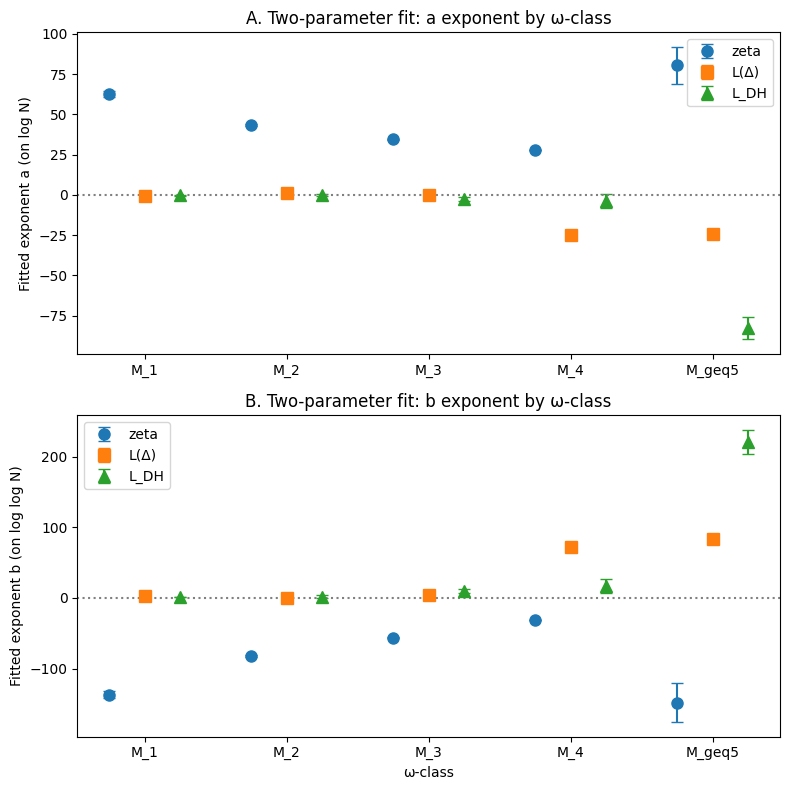

In [8]:
import matplotlib.pyplot as plt

# Final figure: 2-panel summary. 
# A: fitted a exponents (with se) per k for each L. B: fitted b.
ks = ['M_1','M_2','M_3','M_4','M_geq5']
L_list = ['zeta','L(Δ)','L_DH']
colors = {'zeta':'tab:blue','L(Δ)':'tab:orange','L_DH':'tab:green'}
markers = {'zeta':'o','L(Δ)':'s','L_DH':'^'}

fig, axes = plt.subplots(2,1, figsize=(8,8))
xpos = np.arange(len(ks))
width = 0.25
for i,L in enumerate(L_list):
 sub = fit_df[fit_df['L']==L].set_index('k').loc[ks]
 axes[0].errorbar(xpos + (i-1)*width, sub['a_2p'], yerr=sub['se_a'],
 fmt=markers[L], color=colors[L], label=L, capsize=4, ms=8)
 axes[1].errorbar(xpos + (i-1)*width, sub['b_2p'], yerr=sub['se_b'],
 fmt=markers[L], color=colors[L], label=L, capsize=4, ms=8)
axes[0].set_xticks(xpos); axes[0].set_xticklabels(ks)
axes[1].set_xticks(xpos); axes[1].set_xticklabels(ks)
axes[0].axhline(0, color='gray', ls=':')
axes[1].axhline(0, color='gray', ls=':')
axes[0].set_ylabel('Fitted exponent a (on log N)')
axes[1].set_ylabel('Fitted exponent b (on log log N)')
axes[0].set_title('A. Two-parameter fit: a exponent by ω-class')
axes[1].set_title('B. Two-parameter fit: b exponent by ω-class')
axes[0].legend(); axes[1].legend()
axes[1].set_xlabel('ω-class')
plt.tight_layout()
plt.savefig('two_param_fits_summary.png', dpi=150)
plt.show()
